# 淘宝用户行为数据分析 - 数据探索

## 1. 加载数据

本Notebook用于对淘宝用户行为数据集进行初步探索和理解。

In [1]:
import sys
sys.path.append('../src')

from data_loader import load_raw_item_data,load_raw_user_data
from plot_utils import behavior_distribution

user_df = load_raw_user_data()
print(f'加载成功，共读取到{len(user_df)}条用户数据')
item_df = load_raw_item_data()
print(f'加载成功，共读取到{len(item_df)}条商品数据')

加载成功，共读取到12256906条用户数据
加载成功，共读取到480723条商品数据


## 2.数据概览

In [2]:
print('用户数据样本')
print(user_df.head())
print(user_df.sample(5))
print(user_df.tail())

print('\n')

print('商品数据样本')
print(item_df.head())
print(item_df.sample(5))
print(item_df.tail())

用户数据样本
    user_id    item_id  behavior_type user_geohash  item_category  \
0  98047837  232431562              1          NaN           4245   
1  97726136  383583590              1          NaN           5894   
2  98607707   64749712              1          NaN           2883   
3  98662432  320593836              1      96nn52n           6562   
4  98145908  290208520              1          NaN          13926   

                 time        date  hour behavior_label  
0 2014-12-06 02:00:00  2014-12-06     2             浏览  
1 2014-12-09 20:00:00  2014-12-09    20             浏览  
2 2014-12-18 11:00:00  2014-12-18    11             浏览  
3 2014-12-06 10:00:00  2014-12-06    10             浏览  
4 2014-12-16 21:00:00  2014-12-16    21             浏览  
            user_id    item_id  behavior_type user_geohash  item_category  \
11054183   61472535  191726425              1      95r2u4a           3783   
671904     51689371  207819792              1      96bp5rd          13922   
40786

## 3.数据信息查看

In [3]:
print('用户基本信息')
print(user_df.info())
print(user_df.describe())
print(user_df.dtypes)

print('\n')

print('商品基本信息')
print(item_df.info())
print(item_df.describe())
print(item_df.dtypes)

用户基本信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12256906 entries, 0 to 12256905
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   user_id         int64         
 1   item_id         int64         
 2   behavior_type   int64         
 3   user_geohash    object        
 4   item_category   int64         
 5   time            datetime64[ns]
 6   date            object        
 7   hour            int32         
 8   behavior_label  object        
dtypes: datetime64[ns](1), int32(1), int64(4), object(3)
memory usage: 794.9+ MB
None
            user_id       item_id  behavior_type  item_category  \
count  1.225691e+07  1.225691e+07   1.225691e+07   1.225691e+07   
mean   7.170732e+07  2.023084e+08   1.105271e+00   6.846162e+03   
min    4.913000e+03  6.400000e+01   1.000000e+00   2.000000e+00   
25%    3.584965e+07  1.014130e+08   1.000000e+00   3.721000e+03   
50%    7.292804e+07  2.021359e+08   1.000000e+00   6.209000e+0

## 4.缺失值分析

In [4]:
print('商品数据')
print(f'缺失值总数：{item_df.isnull().sum()}')
print(f'缺失率：{item_df.isnull().sum()/len(item_df)*100}')

print('\n')

print('用户数据')
print(f'缺失值总数{user_df.isnull().sum()}')
print(f'缺失率：{user_df.isnull().sum()/len(user_df)*100}')

商品数据
缺失值总数：item_id               0
item_geohash     307063
item_category         0
dtype: int64
缺失率：item_id           0.000000
item_geohash     63.875246
item_category     0.000000
dtype: float64


用户数据
缺失值总数user_id                 0
item_id                 0
behavior_type           0
user_geohash      8334824
item_category           0
time                    0
date                    0
hour                    0
behavior_label          0
dtype: int64
缺失率：user_id            0.000000
item_id            0.000000
behavior_type      0.000000
user_geohash      68.001044
item_category      0.000000
time               0.000000
date               0.000000
hour               0.000000
behavior_label     0.000000
dtype: float64


## 5.行为类型分布

In [5]:
behavior_status = user_df['behavior_type'].value_counts()
print(behavior_status)

behavior_type
1    11550581
3      343564
2      242556
4      120205
Name: count, dtype: int64


数据可视化

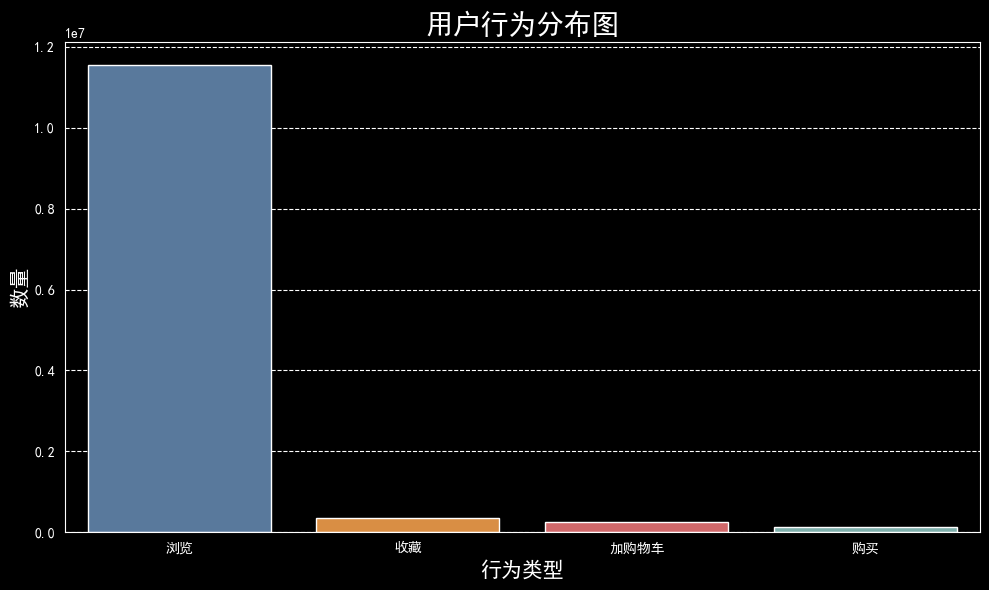

In [6]:
behavior_distribution(user_df)

各种行为的具体占比

In [7]:
pv_rate = behavior_status[1]/behavior_status.sum()*100
print(f'浏览率：{pv_rate}')

cart_rate = behavior_status[2]/behavior_status.sum()*100
print(f'收藏率：{cart_rate}')

favorite_rate = behavior_status[3]/behavior_status.sum()*100
print(f'加购率：{favorite_rate}')

buy_rate = behavior_status[4]/behavior_status.sum()*100
print(f'购买率：{buy_rate}')

浏览率：94.23733036706
收藏率：1.9789333458215312
加购率：2.803023862628954
购买率：0.9807124244895082


## 6.时间范围

In [8]:
print(f'时间范围：{user_df['time'].min()} - {user_df['time'].max()}')

时间范围：2014-11-18 00:00:00 - 2014-12-18 23:00:00


## 7.基础统计

In [9]:
print(f'用户数量：{len(user_df['user_id'].unique())}')
print(f'商品数量：{len(item_df['item_id'].unique())}')
print(f'商品类别数：{len(item_df['item_category'].unique())}')

用户数量：10000
商品数量：310582
商品类别数：991
